# ROUND1 EDA — `ASH_COATED_OSMIUM` & `INTARIAN_PEPPER_ROOT`

Visual exploration of the order book snapshots (`prices_round_1_day_*.csv`) and executed trades (`trades_round_1_day_*.csv`) in the `ROUND1/` folder.

**Sections**
1. Load & stitch the 3 days (−2, −1, 0)
2. Mid-price time series per product
3. Spread & book depth
4. Returns distribution & volatility
5. Rolling statistics (mean, std)
6. Autocorrelation of returns
7. Cross-product relationship (level + returns)
8. Executed trades — price/volume over time
9. Microprice vs mid (order-flow imbalance signal)

Products are abbreviated as:
- **ACO** = `ASH_COATED_OSMIUM`
- **IPR** = `INTARIAN_PEPPER_ROOT`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("ROUND1")
PRODUCTS = ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]
SHORT = {"ASH_COATED_OSMIUM": "ACO", "INTARIAN_PEPPER_ROOT": "IPR"}
COLORS = {"ACO": "#1f77b4", "IPR": "#d62728"}

## 1. Load prices & trades across all days

Each day has its own timestamp starting at 0. We create a global `t` = `day * 1_000_000 + timestamp` so the 3 days lay out end-to-end on a single axis.

In [2]:
def load_prices(folder: Path) -> pd.DataFrame:
    frames = []
    for p in sorted(folder.glob("prices_round_1_day_*.csv")):
        frames.append(pd.read_csv(p, sep=";"))
    df = pd.concat(frames, ignore_index=True)
    day_offset = (df["day"] - df["day"].min()) * 1_000_000
    df["t"] = day_offset + df["timestamp"]
    return df.sort_values(["t", "product"]).reset_index(drop=True)

def load_trades(folder: Path) -> pd.DataFrame:
    frames = []
    for p in sorted(folder.glob("trades_round_1_day_*.csv")):
        d = pd.read_csv(p, sep=";")
        day_num = int(str(p).split("day_")[-1].split(".")[0])
        d["day"] = day_num
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    day_offset = (df["day"] - df["day"].min()) * 1_000_000
    df["t"] = day_offset + df["timestamp"]
    return df.sort_values("t").reset_index(drop=True)

prices = load_prices(DATA_DIR)
trades = load_trades(DATA_DIR)
print("prices rows:", len(prices), "| days:", sorted(prices['day'].unique()))
print("trades rows:", len(trades), "| products:", trades['symbol'].unique())
prices.head()

prices rows: 60000 | days: [np.int64(-2), np.int64(-1), np.int64(0)]
trades rows: 2276 | products: ['ASH_COATED_OSMIUM' 'INTARIAN_PEPPER_ROOT']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,t
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
1,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0
2,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100
3,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100
4,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,200


In [3]:
def pivot_mid(df: pd.DataFrame) -> pd.DataFrame:
    m = df.pivot_table(index="t", columns="product", values="mid_price", aggfunc="last")
    m = m.sort_index().ffill().dropna()
    m.columns = [SHORT[c] for c in m.columns]
    return m

mids = pivot_mid(prices)
mids.describe()

,ACO,IPR
count,30000.000000,30000.000000
mean,9983.870567,11479.188750
std,403.865355,993.184832
min,0.000000,0.000000
25%,9997.000000,10745.500000
50%,10000.500000,11497.500000
75%,10003.500000,12248.500000
max,10023.000000,13007.000000


## 2. Mid-price over time (per product, per day)

Vertical dashed lines mark day boundaries.

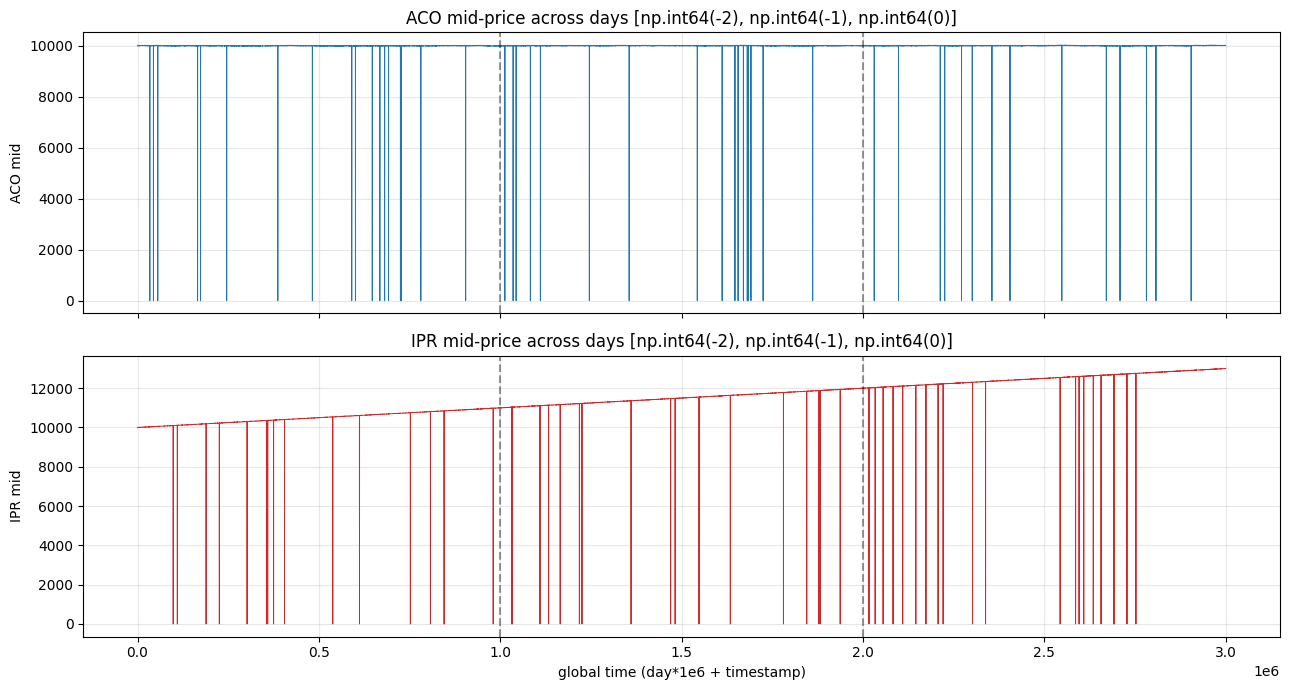

In [4]:
day_breaks = sorted(prices["day"].unique())
day_bounds = [(d - min(day_breaks)) * 1_000_000 for d in day_breaks]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, col in zip(axes, ["ACO", "IPR"]):
    ax.plot(mids.index, mids[col], color=COLORS[col], lw=0.7)
    ax.set_ylabel(f"{col} mid")
    ax.set_title(f"{col} mid-price across days {day_breaks}")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
axes[-1].set_xlabel("global time (day*1e6 + timestamp)")
plt.tight_layout()
plt.show()

## 3. Spread (best ask − best bid) and top-of-book depth

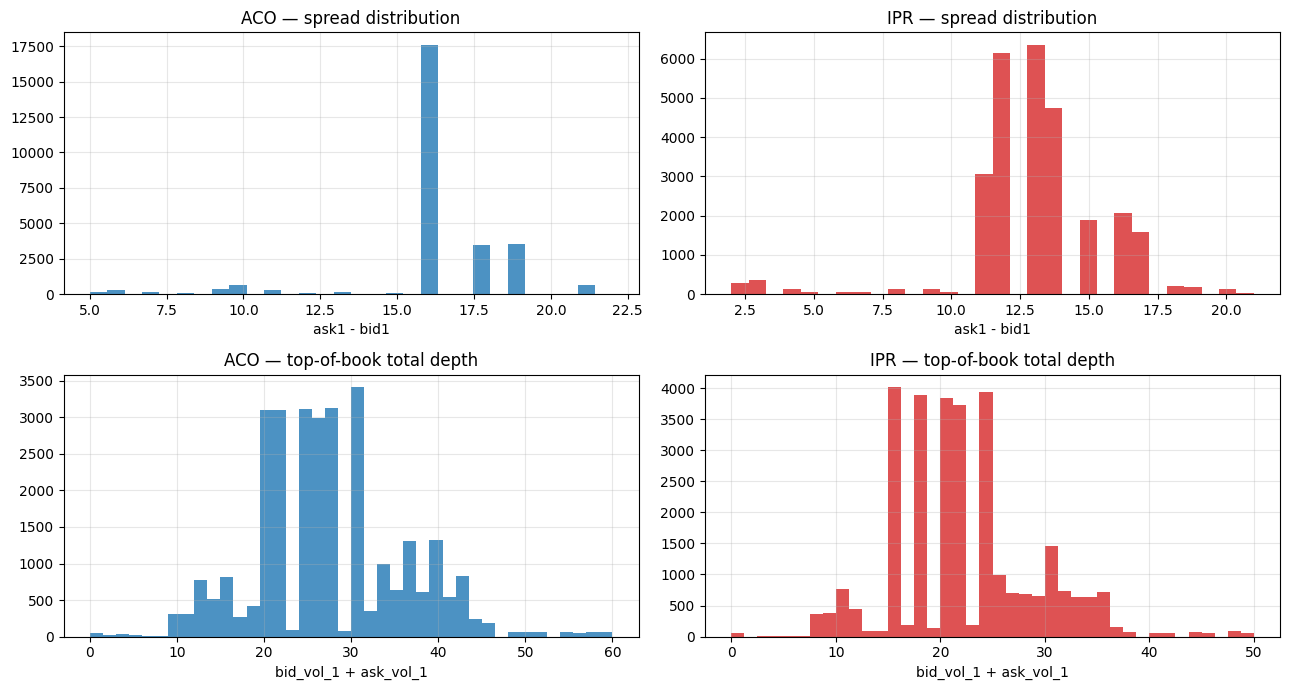

product          ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
spread    count       27644.000000          27688.000000
          mean           16.175228             13.046699
          std             2.570999              2.627145
          min             5.000000              2.000000
          25%            16.000000             12.000000
          50%            16.000000             13.000000
          75%            18.000000             14.000000
          max            22.000000             21.000000
depth_top count       30000.000000          30000.000000
          mean           27.151667             22.156800
          std             8.576339              6.852555
          min             0.000000              0.000000
          25%            22.000000             18.000000
          50%            26.000000             22.000000
          75%            31.000000             25.000000
          max            60.000000             50.000000

In [5]:
p = prices.copy()
p["spread"] = p["ask_price_1"] - p["bid_price_1"]
p["depth_top"] = p["ask_volume_1"].fillna(0) + p["bid_volume_1"].fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for i, prod in enumerate(PRODUCTS):
    sub = p[p["product"] == prod]
    c = COLORS[SHORT[prod]]
    axes[0, i].hist(sub["spread"].dropna(), bins=30, color=c, alpha=0.8)
    axes[0, i].set_title(f"{SHORT[prod]} — spread distribution")
    axes[0, i].set_xlabel("ask1 - bid1")
    axes[1, i].hist(sub["depth_top"], bins=40, color=c, alpha=0.8)
    axes[1, i].set_title(f"{SHORT[prod]} — top-of-book total depth")
    axes[1, i].set_xlabel("bid_vol_1 + ask_vol_1")
plt.tight_layout()
plt.show()

p.groupby("product")[["spread", "depth_top"]].describe().T

## 4. Returns distribution & volatility

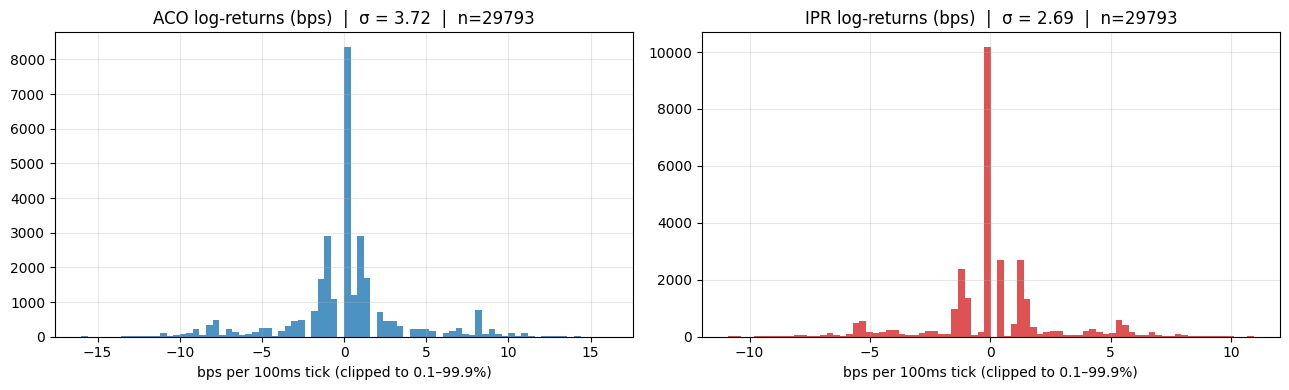

summary (bps):
         mean       std        min        max
ACO -0.001141  3.717838 -21.015770  21.003158
IPR  0.087151  2.692048 -15.846469  13.874973


In [7]:
mids_pos = mids.where(mids > 0)
rets = np.log(mids_pos).diff() * 1e4  # bps
rets = rets.replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["ACO", "IPR"]):
    x = rets[col].to_numpy()
    x = x[np.isfinite(x)]
    if x.size == 0:
        ax.set_title(f"{col} — no finite returns")
        continue
    lo, hi = np.quantile(x, [0.001, 0.999])
    xc = x[(x >= lo) & (x <= hi)] if hi > lo else x
    ax.hist(xc, bins=80, color=COLORS[col], alpha=0.8)
    ax.set_title(f"{col} log-returns (bps)  |  σ = {x.std():.2f}  |  n={len(x)}")
    ax.set_xlabel("bps per 100ms tick (clipped to 0.1–99.9%)")
plt.tight_layout()
plt.show()

print("summary (bps):")
print(rets.agg(["mean", "std", "min", "max"]).T)

## 5. Rolling mean & std (window = 100 ticks ≈ 10s)

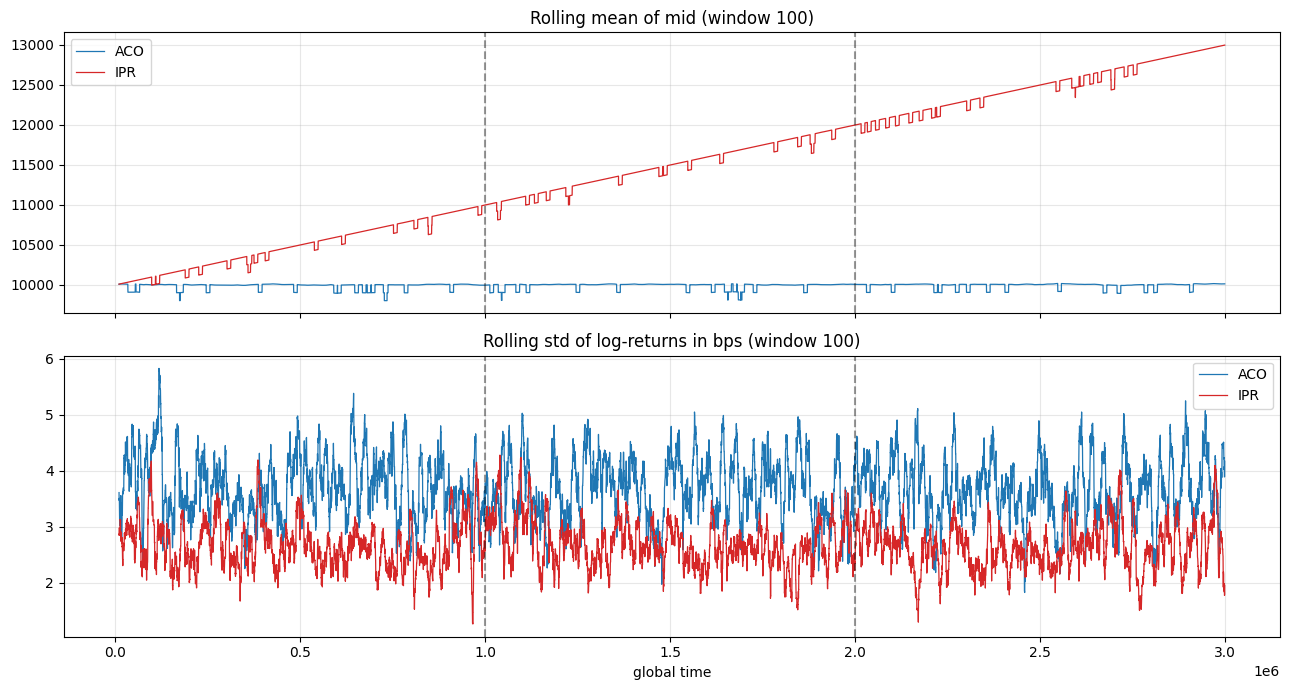

In [8]:
WIN = 100
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for col in ["ACO", "IPR"]:
    axes[0].plot(mids.index, mids[col].rolling(WIN).mean(), color=COLORS[col], label=col, lw=0.9)
    axes[1].plot(rets.index, rets[col].rolling(WIN).std(), color=COLORS[col], label=col, lw=0.9)
axes[0].set_title(f"Rolling mean of mid (window {WIN})")
axes[0].legend()
axes[1].set_title(f"Rolling std of log-returns in bps (window {WIN})")
axes[1].set_xlabel("global time")
axes[1].legend()
for b in day_bounds[1:]:
    for ax in axes:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Autocorrelation of returns

Negative short-lag ACF ⇒ mean-reverting micro-structure, which favors aggressive mid reversion / microprice fair.

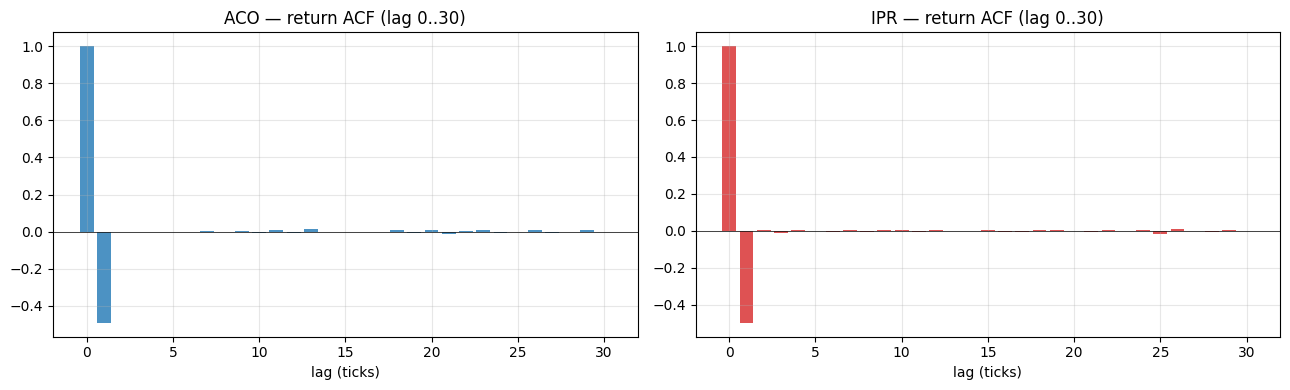

In [9]:
def acf(x: np.ndarray, lags: int = 30) -> np.ndarray:
    x = x - x.mean()
    v = np.dot(x, x)
    if v < 1e-20:
        return np.full(lags + 1, np.nan)
    return np.array([np.dot(x[: len(x) - k], x[k:]) / v for k in range(lags + 1)])

LAGS = 30
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["ACO", "IPR"]):
    a = acf(rets[col].values, LAGS)
    ax.bar(range(LAGS + 1), a, color=COLORS[col], alpha=0.8)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{col} — return ACF (lag 0..{LAGS})")
    ax.set_xlabel("lag (ticks)")
plt.tight_layout()
plt.show()

## 7. Cross-product relationship

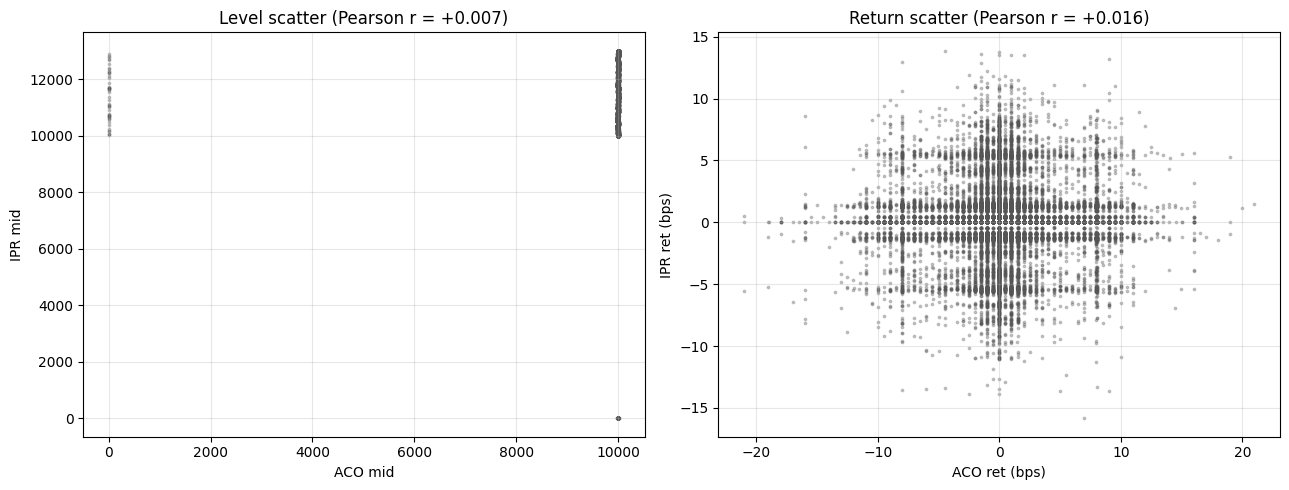

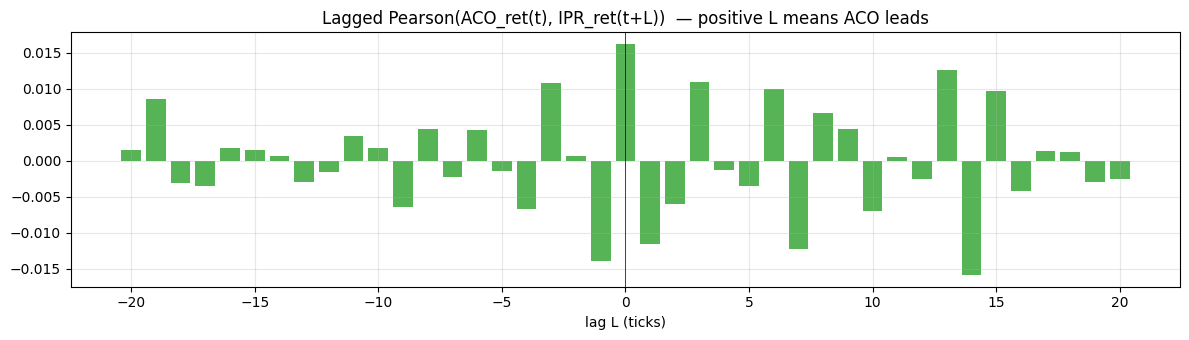

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(mids["ACO"], mids["IPR"], s=3, alpha=0.3, color="#555")
axes[0].set_xlabel("ACO mid"); axes[0].set_ylabel("IPR mid")
axes[0].set_title(f"Level scatter (Pearson r = {mids.corr().iloc[0,1]:+.3f})")

axes[1].scatter(rets["ACO"], rets["IPR"], s=3, alpha=0.3, color="#555")
axes[1].set_xlabel("ACO ret (bps)"); axes[1].set_ylabel("IPR ret (bps)")
axes[1].set_title(f"Return scatter (Pearson r = {rets.corr().iloc[0,1]:+.3f})")
plt.tight_layout()
plt.show()

lags = range(-20, 21)
ac = rets["ACO"].values; ip = rets["IPR"].values
xcorr = []
for L in lags:
    if L >= 0:
        a, b = ac[: len(ac) - L], ip[L:]
    else:
        a, b = ac[-L:], ip[: len(ip) + L]
    if len(a) < 5 or a.std() == 0 or b.std() == 0:
        xcorr.append(np.nan); continue
    xcorr.append(float(np.corrcoef(a, b)[0, 1]))

plt.figure(figsize=(12, 3.5))
plt.bar(list(lags), xcorr, color="#2ca02c", alpha=0.8)
plt.axvline(0, color="k", lw=0.5)
plt.title("Lagged Pearson(ACO_ret(t), IPR_ret(t+L))  — positive L means ACO leads")
plt.xlabel("lag L (ticks)")
plt.tight_layout()
plt.show()

## 8. Executed trades — price & volume over time

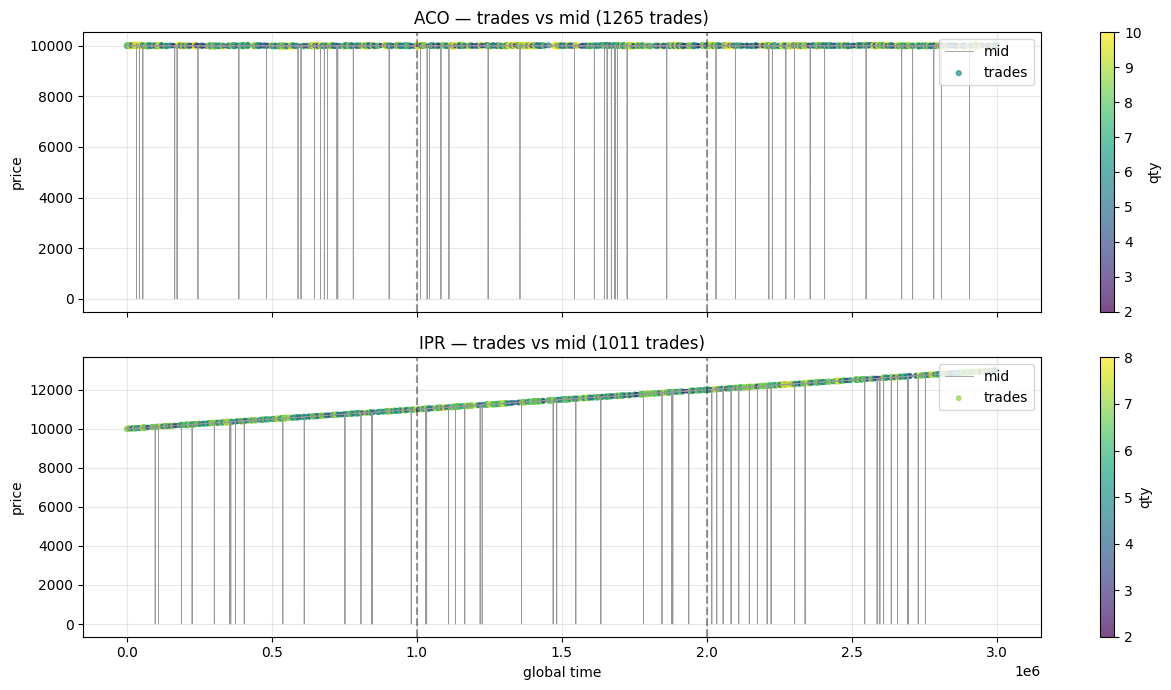

trade qty & price summary per product:


symbol          ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
price    count        1265.000000           1011.000000
         mean        10000.213439          11495.941642
         std             9.398204            879.805548
         min          9979.000000           9995.000000
         25%          9992.000000          10736.000000
         50%         10000.000000          11502.000000
         75%         10008.000000          12251.000000
         max         10026.000000          13005.000000
quantity count        1265.000000           1011.000000
         mean            5.211858              5.173096
         std             2.275214              1.511903
         min             2.000000              2.000000
         25%             3.000000              4.000000
         50%             5.000000              5.000000
         75%             6.000000              6.000000
         max            10.000000              8.000000

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for i, prod in enumerate(PRODUCTS):
    ax = axes[i]
    tr = trades[trades["symbol"] == prod]
    mid_sub = prices[prices["product"] == prod][["t", "mid_price"]]
    ax.plot(mid_sub["t"], mid_sub["mid_price"], color="#999", lw=0.6, label="mid")
    sc = ax.scatter(tr["t"], tr["price"], s=np.clip(tr["quantity"] * 2, 4, 80),
                    c=tr["quantity"], cmap="viridis", alpha=0.7, label="trades")
    plt.colorbar(sc, ax=ax, label="qty")
    ax.set_title(f"{SHORT[prod]} — trades vs mid ({len(tr)} trades)")
    ax.set_ylabel("price")
    ax.legend(loc="upper right")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
axes[-1].set_xlabel("global time")
plt.tight_layout()
plt.show()

print("trade qty & price summary per product:")
trades.groupby("symbol")[["price", "quantity"]].describe().T

## 9. Microprice vs mid — order-flow imbalance signal

Microprice = `ask * (bid_vol / total) + bid * (ask_vol / total)` — pulls fair toward the heavier side of the book. The deviation `micro − mid` is a short-horizon directional signal.

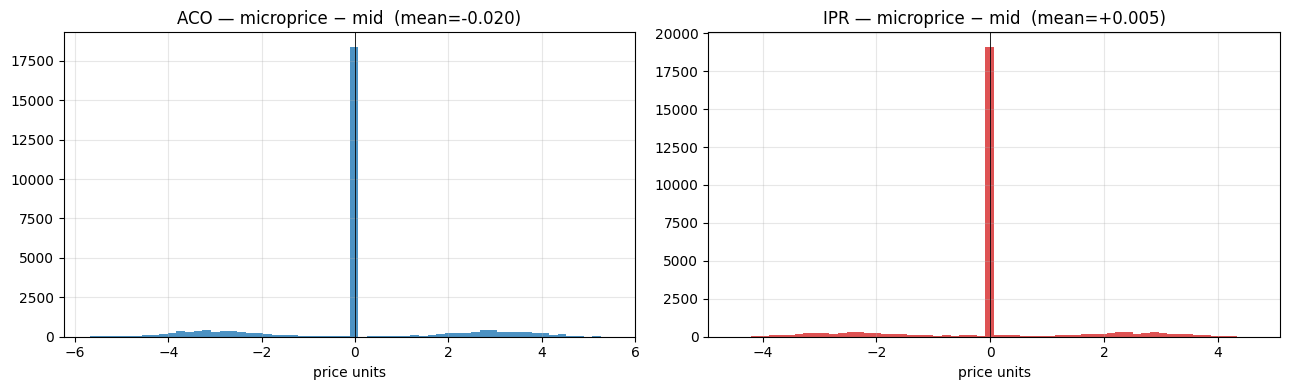

In [12]:
q = prices.copy()
bv = q["bid_volume_1"].fillna(0); av = q["ask_volume_1"].fillna(0)
tot = (bv + av).replace(0, np.nan)
q["micro"] = q["ask_price_1"] * (bv / tot) + q["bid_price_1"] * (av / tot)
q["micro_dev"] = q["micro"] - q["mid_price"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, prod in zip(axes, PRODUCTS):
    sub = q[q["product"] == prod]["micro_dev"].dropna()
    ax.hist(sub, bins=60, color=COLORS[SHORT[prod]], alpha=0.8)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{SHORT[prod]} — microprice − mid  (mean={sub.mean():+.3f})")
    ax.set_xlabel("price units")
plt.tight_layout()
plt.show()

---
### Takeaways to look for
- Is one product pinned near a round number (low vol) while the other drifts (high vol)?
- Short-lag ACF sign → favors microprice (negative) vs momentum (positive).
- Cross-return correlation → whether a pair signal / hedge is viable.
- Trade clusters relative to mid → where aggressors pay up; informs passive edge vs cross-the-spread PnL.